# Lab 3: Federated Learning — Medical Datasets
Comparing FedAvg, SCAFFOLD on Medical and Cardio datasets.

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

cwd = Path.cwd()
if (cwd / 'runs').exists():
    base_dir = cwd / 'runs'
elif cwd.name == 'runs':
    base_dir = cwd
else:
    base_dir = cwd / 'runs'

plot_dir = base_dir / 'plots' / 'lab_2'
plot_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(plot_dir / name, dpi=200, bbox_inches='tight')
    print(f"Saved plot: {plot_dir / name}")

## 1. Data Loading Helper Functions

In [2]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the global metrics (like accuracy per round)."""
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv' # Fallback
    
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    return None

def load_locals_metrics(run_path: Path) -> pd.DataFrame:
    """Loads the per-client local metrics."""
    path = run_path / 'locals_metrics.csv'
    return pd.read_csv(path) if path.exists() else None

def load_comm_costs(run_path: Path):
    """Loads communication costs."""
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    """Loads the total run time in seconds."""
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return 0.0
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    return float(row['value'].iloc[0]) if not row.empty else 0.0

def comm_to_mb(comm_df):
    """Converts communication costs from bytes/parameters to Megabytes."""
    if comm_df is None or comm_df.empty:
        return 0.0
    return (comm_df['comm_costs'].sum() * 4) / (1024**2)

def get_final_metric(run_path: Path, metric: str):
    """Gets the final-round value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].iloc[-1]
    return None

def get_best_metric(run_path: Path, metric: str):
    """Gets the best (max) value of a metric."""
    df = load_global_metrics(Path(run_path))
    if df is not None and metric in df.columns:
        return df[metric].max()
    return None

## 2. Generic Plotting Functions

In [3]:
MODEL_COLORS = {
    'MLP': '#2196F3',
    'LogReg': '#F44336',
}

LINESTYLES = ['-', '--', '-.', ':']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']


def plot_evolution_metric(experiments_dict, metric='accuracy', title='Model Comparison',
                          filename='evolution.png', ylabel=None, mark_every=5):
    """Plots a line chart of a given metric (e.g., accuracy) over communication rounds."""
    plt.figure(figsize=(12, 7))
    cm = plt.get_cmap('tab10')
    
    plotted_any = False
    
    for i, (path, label) in enumerate(experiments_dict.items()):
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            color = cm(i % 10)
            l_style = LINESTYLES[i % len(LINESTYLES)]
            marker = MARKERS[i % len(MARKERS)]
            
            plt.plot(df['round'], df[metric], 
                     color=color, linestyle=l_style, linewidth=2, label=str(label),
                     marker=marker, markersize=4, markevery=mark_every)
            plotted_any = True
        else:
            print(f"\u26a0\ufe0f Warning: Could not load metric '{metric}' for '{label}' at {path}")
            
    if plotted_any:
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Communication Round', fontsize=12)
        plt.ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_fig(filename)
        plt.show()
    else:
        print("No data available to plot.")


def plot_cost_summary(experiments_dict, title='Cost Summary', filename='costs.png'):
    """Plots a dual-axis bar chart comparing Time (seconds) and Comm Costs (MB)."""
    times = []
    comms = []
    valid_labels = []
    
    for path, label in experiments_dict.items():
        p = Path(path)
        if not p.exists():
            print(f"\u26a0\ufe0f Warning: Path not found: {p}")
            continue
            
        times.append(load_run_time(p))
        comms.append(comm_to_mb(load_comm_costs(p)))
        valid_labels.append(str(label))
        
    if not times:
        print("No data to plot for costs.")
        return

    x = np.arange(len(valid_labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(max(10, len(valid_labels) * 1.8), 7))

    # Time (Left Y-Axis)
    color1 = '#E76F51' # Orange/Red
    ax1.set_xlabel('Experiment Configuration', fontsize=12)
    ax1.set_ylabel('Total Time (s)', color=color1, fontsize=12)
    rects1 = ax1.bar(x - width/2, times, width, label='Time (s)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Add time values on top of bars
    for bar in rects1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}s', 
                 ha='center', va='bottom', fontsize=10, color=color1)

    # Communication (Right Y-Axis)
    ax2 = ax1.twinx()  
    color2 = '#2A9D8F'
    ax2.set_ylabel('Total Communication (MB)', color=color2, fontsize=12)  
    rects2 = ax2.bar(x + width/2, comms, width, label='Comm (MB)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    for bar in rects2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                 ha='center', va='bottom', fontsize=10, color=color2)

    ax1.set_xticks(x)
    ax1.set_xticklabels(valid_labels, rotation=45, ha="right")
    plt.title(title, fontsize=14, fontweight='bold')
    fig.tight_layout()  
    save_fig(filename)
    plt.show()


def plot_bar_comparison(experiments_dict, metric='accuracy', title='Comparison',
                        filename='bar.png', ylabel=None, use_final_round=True):
    """Plots a bar chart comparing the final (or best) value of a metric across experiments."""
    values = []
    labels = []

    for path, label in experiments_dict.items():
        df = load_global_metrics(Path(path))
        if df is not None and metric in df.columns:
            if use_final_round:
                val = df[metric].iloc[-1]
            else:
                val = df[metric].max()
            values.append(val)
            labels.append(str(label))

    if not values:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.5), 6))
    cm = plt.get_cmap('tab10')
    colors = [cm(i % 10) for i in range(len(labels))]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_utility_vs_cost(experiments_dict, utility_metric='accuracy',
                         title='Utility vs Cost', filename='utility_vs_cost.png'):
    """Scatter plot: accuracy (utility) vs training time (cost)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    cm = plt.get_cmap('tab10')

    for i, (path, label) in enumerate(experiments_dict.items()):
        p = Path(path)
        df = load_global_metrics(p)
        t = load_run_time(p)
        if df is not None and utility_metric in df.columns and t > 0:
            final_val = df[utility_metric].iloc[-1]
            color = cm(i % 10)
            marker = MARKERS[i % len(MARKERS)]
            ax.scatter(t, final_val, color=color, marker=marker, s=200, label=str(label),
                       edgecolors='black', linewidths=0.8, zorder=5)
            ax.annotate(str(label), (t, final_val), textcoords='offset points',
                        xytext=(10, 5), fontsize=9)

    ax.set_xlabel('Training Time (s) \u2014 Cost', fontsize=12)
    ax.set_ylabel(f'{utility_metric.replace("_", " ").title()} \u2014 Utility', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_metric_vs_param(model_data, param_name, metric, title, filename,
                         ylabel=None, use_best=False):
    """
    Generic: plot a metric against a swept parameter for both models side-by-side.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        values = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                params.append(param_val)
                values.append(val)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, values, color=color, linewidth=2.5, label=model_name,
                    marker='o', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, vv in zip(params, values):
                ax.annotate(f'{vv:.4f}', (pv, vv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_time_vs_param(model_data, param_name, title, filename):
    """
    Plot training time against a swept parameter for both models.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name, entries in model_data.items():
        params = []
        times = []
        for param_val, run_path in sorted(entries, key=lambda x: x[0]):
            p = Path(run_path)
            t = load_run_time(p)
            if t > 0:
                params.append(param_val)
                times.append(t)

        if params:
            color = MODEL_COLORS.get(model_name, '#666666')
            ax.plot(params, times, color=color, linewidth=2.5, label=model_name,
                    marker='s', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
            for pv, tv in zip(params, times):
                ax.annotate(f'{tv:.1f}s', (pv, tv), textcoords='offset points',
                            xytext=(0, 10), ha='center', fontsize=9)

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Training Time (s)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def plot_grouped_bars(model_data, param_name, metric, title, filename,
                      ylabel=None, use_best=False):
    """
    Grouped bar chart: one group per param value, bars for each model.
    
    model_data: dict of {model_name: [(param_value, run_path), ...]}
    """
    all_params = sorted(set(
        pv for entries in model_data.values() for pv, _ in entries
    ))
    model_names = list(model_data.keys())
    n_models = len(model_names)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(all_params) * 2), 6))
    x = np.arange(len(all_params))

    for mi, model_name in enumerate(model_names):
        lookup = {}
        for pv, rp in model_data[model_name]:
            p = Path(rp)
            if use_best:
                val = get_best_metric(p, metric)
            else:
                val = get_final_metric(p, metric)
            if val is not None:
                lookup[pv] = val

        vals = [lookup.get(pv, 0) for pv in all_params]
        offset = (mi - (n_models - 1) / 2) * width
        color = MODEL_COLORS.get(model_name, plt.get_cmap('tab10')(mi))
        bars = ax.bar(x + offset, vals, width * 0.9, label=model_name, color=color,
                       edgecolor='white', linewidth=1)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(p) for p in all_params])
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_fig(filename)
    plt.show()

## 3. Define the Experiments to Compare

In [4]:
# ── Lab 3 Experiments ──
lab_3_experiments = {
    base_dir / "lab_3_med_experiment_iid": "Med IID (FedAvg)",
    base_dir / "lab_3_med_experiment_iid_cardio": "Cardio IID (FedAvg)",
    base_dir / "lab_3_med_experiment_iid_scaffold": "Med IID (SCAFFOLD)",
}

# The user might add more configs later, they can just append them to this dictionary.
print("Lab 3 experiments loaded:")
for p, l in lab_3_experiments.items():
    exists = '✅' if Path(p).exists() else '❌'
    print(f"  {exists} {l}: {p}")


Lab 3 experiments loaded:
  ✅ Med IID (FedAvg): /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/lab_3_med_experiment_iid
  ✅ Cardio IID (FedAvg): /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/lab_3_med_experiment_iid_cardio
  ✅ Med IID (SCAFFOLD): /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/lab_3_med_experiment_iid_scaffold


---
## 4. Accuracy & F1 over FL Rounds

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/lab3_accuracy.png


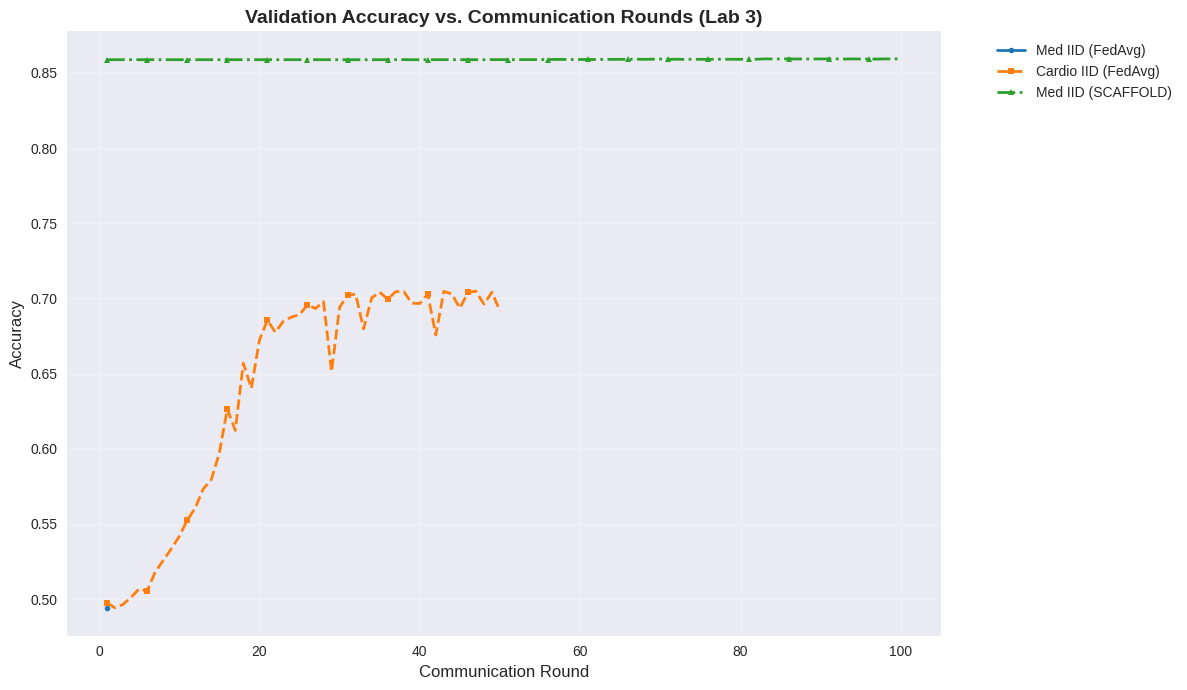

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/lab3_macro_f1.png


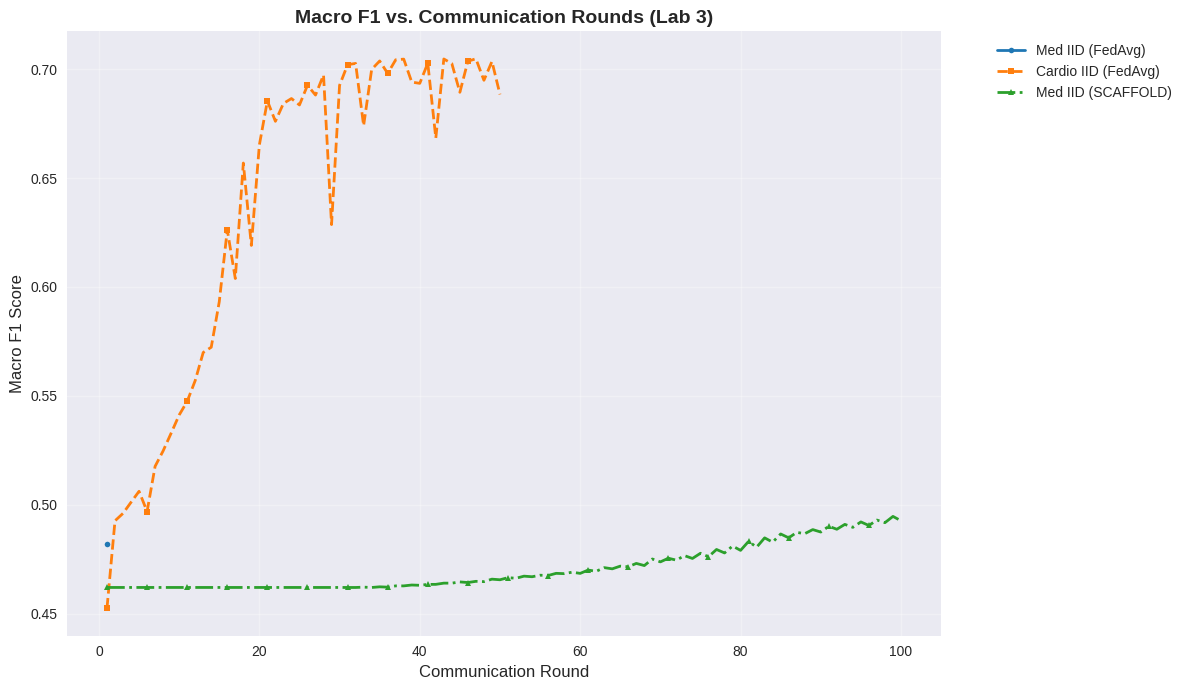

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/lab3_micro_f1.png


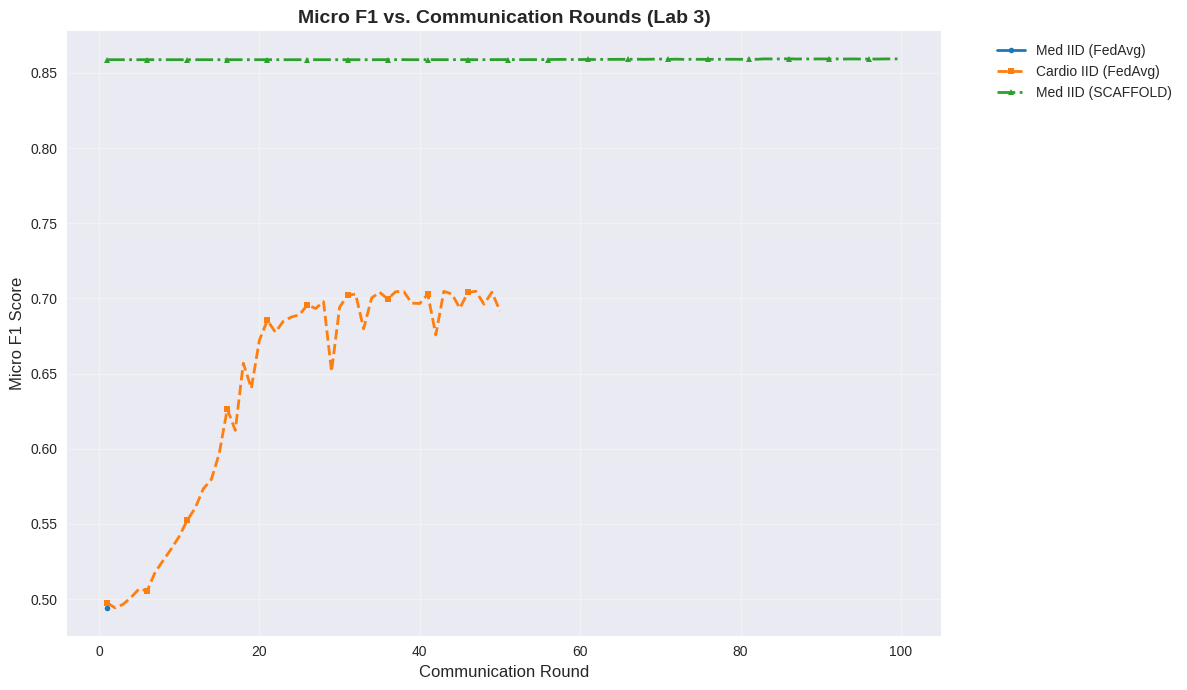

In [5]:
plot_evolution_metric(lab_3_experiments, metric='accuracy', 
                      title='Validation Accuracy vs. Communication Rounds (Lab 3)', 
                      filename='lab3_accuracy.png',
                      ylabel='Accuracy')

plot_evolution_metric(lab_3_experiments, metric='macro_f1',
                      title='Macro F1 vs. Communication Rounds (Lab 3)',
                      filename='lab3_macro_f1.png',
                      ylabel='Macro F1 Score')

plot_evolution_metric(lab_3_experiments, metric='micro_f1',
                      title='Micro F1 vs. Communication Rounds (Lab 3)',
                      filename='lab3_micro_f1.png',
                      ylabel='Micro F1 Score')


---
## 5. Cost Analysis

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/lab3_costs.png


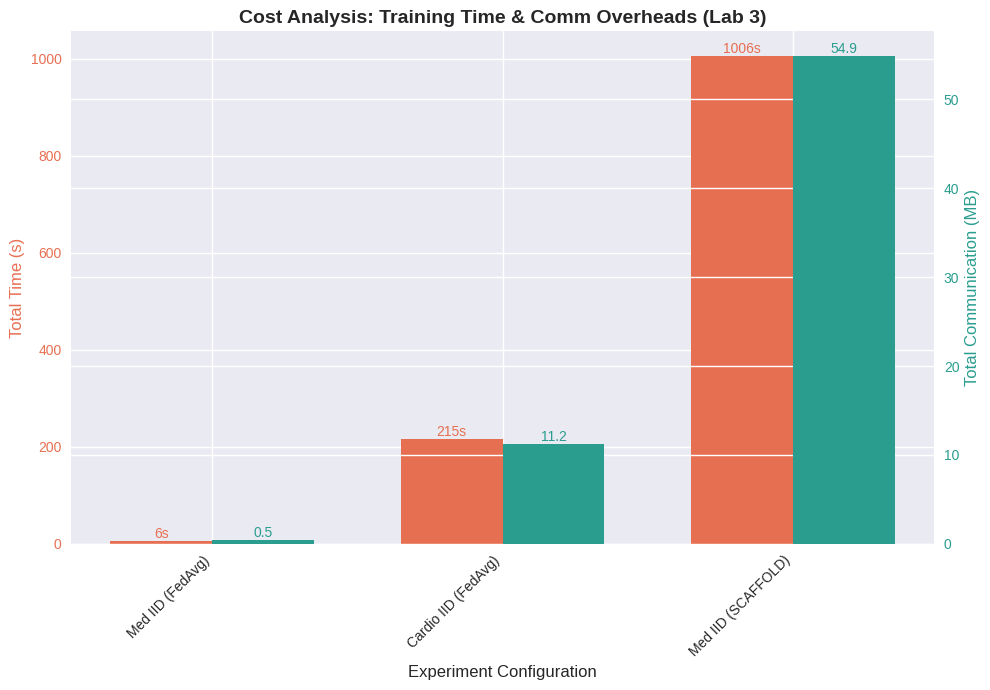

In [6]:
plot_cost_summary(lab_3_experiments,
                  title='Cost Analysis: Training Time & Comm Overheads (Lab 3)',
                  filename='lab3_costs.png')


---
## 6. Utility vs Cost

Saved plot: /home/romain/dev/Master/federated_repo/flds-insa-lyon-federated-learning-for-distributed-system/romprr_repo/runs/plots/lab_2/lab3_utility_vs_cost.png


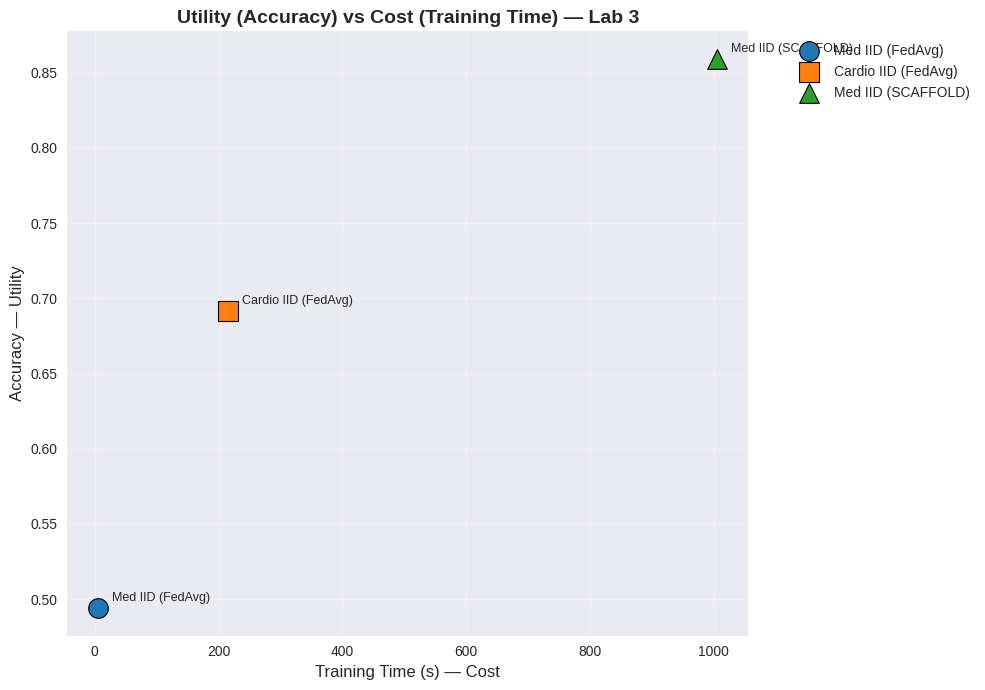

In [7]:
plot_utility_vs_cost(lab_3_experiments, utility_metric='accuracy',
                     title='Utility (Accuracy) vs Cost (Training Time) — Lab 3',
                     filename='lab3_utility_vs_cost.png')
